## Executive Summary

This project predicts the total value of bike orders and identifies the
characteristics most useful for those predictions.

Key findings:

- The final XGBoost model achieved an R² of approximately 0.91 on an untouched
  holdout set.
- Average absolute prediction error was approximately 139 order-value units.
- XGBoost outperformed the Linear Regression benchmark and remained the
  strongest algorithm after sensitivity testing.
- Hyperparameter tuning, voting and stacking did not improve performance,
  so the simpler original XGBoost model was retained.
- High-value orders were preserved in the primary dataset because they
  represent plausible premium or high-quantity transactions rather than
  obvious data errors.
- Permutation importance is used to identify the strongest predictive drivers
  of order value.

The final model therefore provides strong predictive performance while
retaining coverage of the complete business population.

# Bike Order Value Prediction and Price Driver Analysis

## Business Objective

This project develops a machine-learning model to predict the total value of a bike order based on product, order, and geographic characteristics.

The analysis has two objectives:

1. Predict total bike order value as accurately as possible.
2. Identify the product, order, and location characteristics that have the strongest relationship with total order value.

## Target Variable

`total_price`

## Candidate Features

* Quantity
* Bike model
* Product category
* Frame material
* City
* State

## Model Evaluation

Models will primarily be compared using:

* **RMSE** — penalises large prediction errors.
* **MAE** — represents the average absolute prediction error.
* **R²** — represents the proportion of variance in total order value explained by the model.

Model selection will consider both predictive accuracy and model simplicity.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.core.frame import DataFrame
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import sklearn
print(sklearn.__version__)

1.6.1


# Import Data
## Data Source

The dataset contains historical bike order-line transactions. In this notebook, the data is loaded from Google Sheets into a Pandas DataFrame. A local CSV copy should be supplied with the public project so that the analysis can be reproduced without private account access.

In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

worksheet = gc.open('bike_orderlines_df').sheet1

values_list = worksheet.get_all_values()
df = pd.DataFrame(values_list)
df=df.iloc[1:,:]
columns = values_list[0]
df.columns = columns
#df=df.drop(['sfdc_account_id'],axis=1)
df

,,order_id,order_line,order_date,model,quantity,price,total_price,category_1,category_2,frame_material,city,state
1,0,1,1,2011-01-07,Jekyll Carbon 2,1,6070,6070,Mountain,Over Mountain,Carbon,Ithaca,NY
2,1,1,2,2011-01-07,Trigger Carbon 2,1,5970,5970,Mountain,Over Mountain,Carbon,Ithaca,NY
3,2,2,1,2011-01-10,Beast of the East 1,1,2770,2770,Mountain,Trail,Aluminum,Kansas City,KS
4,3,2,2,2011-01-10,Trigger Carbon 2,1,5970,5970,Mountain,Over Mountain,Carbon,Kansas City,KS
5,4,3,1,2011-01-10,Supersix Evo Hi-Mod Team,1,10660,10660,Road,Elite Road,Carbon,Louisville,KY
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15640,15639,2000,4,2015-12-25,CAAD Disc Ultegra,1,2660,2660,Road,Elite Road,Aluminum,Austin,TX
15641,15640,2000,5,2015-12-25,Trail 2,1,1350,1350,Mountain,Sport,Aluminum,Austin,TX
15642,15641,2000,6,2015-12-25,CAAD12 105,1,1680,1680,Road,Elite Road,Aluminum,Austin,TX
15643,15642,2000,7,2015-12-25,F-Si Carbon 4,1,2880,2880,Mountain,Cross Country Race,Carbon,Austin,TX


# Exploratory Data Analysis (EDA)

In [ ]:
#sum the null values in each column
df.isnull().sum()

,0
,0
order_id,0
order_line,0
order_date,0
model,0
quantity,0
price,0
total_price,0
category_1,0
category_2,0


In [ ]:
print (df.dtypes)

                  object
order_id          object
order_line        object
order_date        object
model             object
quantity          object
price             object
total_price       object
category_1        object
category_2        object
frame_material    object
city              object
state             object
dtype: object


In [ ]:
df ['price'] = pd.to_numeric(df['price'], errors='coerce')
df ['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df ['total_price'] = pd.to_numeric(df['total_price'], errors='coerce')
df = df.replace(np.nan, 0, regex=True)
print(df.dtypes)

                  object
order_id          object
order_line        object
order_date        object
model             object
quantity           int64
price              int64
total_price        int64
category_1        object
category_2        object
frame_material    object
city              object
state             object
dtype: object


### Feature Selection Rationale

`quantity` is retained because the number of units purchased is a fundamental
driver of total order value.

The source `price` field is intentionally excluded because `total_price`
appears to be derived from unit price and quantity. Including unit price would
make the prediction task largely arithmetic and could introduce direct target
leakage.

The model therefore attempts to estimate order value from quantity, product
characteristics and geographic information.

In [ ]:
short_df = df[[ 'model','quantity','total_price','category_1','category_2','frame_material','city','state']]
short_df.head()

,model,quantity,total_price,category_1,category_2,frame_material,city,state
1,Jekyll Carbon 2,1,6070,Mountain,Over Mountain,Carbon,Ithaca,NY
2,Trigger Carbon 2,1,5970,Mountain,Over Mountain,Carbon,Ithaca,NY
3,Beast of the East 1,1,2770,Mountain,Trail,Aluminum,Kansas City,KS
4,Trigger Carbon 2,1,5970,Mountain,Over Mountain,Carbon,Kansas City,KS
5,Supersix Evo Hi-Mod Team,1,10660,Road,Elite Road,Carbon,Louisville,KY


In [ ]:
short_df.shape

(15644, 8)

In [ ]:
# check level of cardinality
unique_counts_short_df = pd.DataFrame.from_records([(col, short_df[col].nunique()) for col in short_df.columns],
                          columns=['Column_Name', 'Num_Unique']).sort_values(by=['Num_Unique'])

unique_counts_short_df

,Column_Name,Num_Unique
3,category_1,2
5,frame_material,2
4,category_2,9
1,quantity,10
7,state,21
6,city,30
0,model,97
2,total_price,295


In [ ]:
short_df['model'].value_counts(normalize=True)*100

,proportion
model,
Slice Ultegra D12,1.463820
Supersix Evo Ultegra 3,1.451036
Scalpel 29 4,1.412682
F-Si 2,1.374329
CAAD8 105,1.342368
...,...
Jekyll Carbon 3,0.703145
Habit Carbon 1,0.703145
Synapse Hi-Mod Disc Black Inc.,0.683968


No single bike model dominates the dataset, so there is no immediate indication
that model frequency would disproportionately influence the analysis.

In [ ]:
import matplotlib as plt
import seaborn as sns

<Axes: ylabel='total_price'>

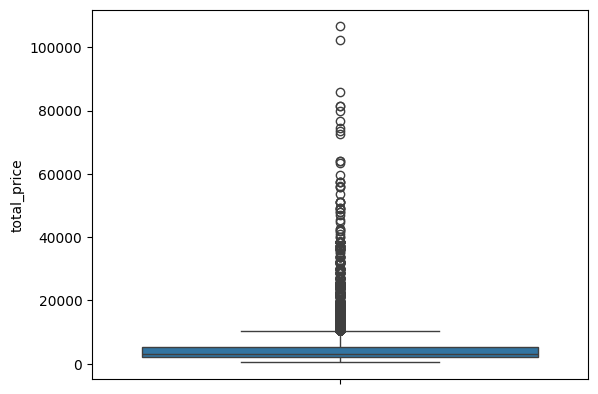

In [ ]:
sns.boxplot( y='total_price', data=short_df)

In [ ]:
short_df['total_price'].describe()

,total_price
count,15644.000000
mean,4540.547814
std,5190.871394
min,415.000000
25%,1950.000000
50%,3200.000000
75%,5330.000000
max,106600.000000


<Axes: xlabel='category_2', ylabel='total_price'>

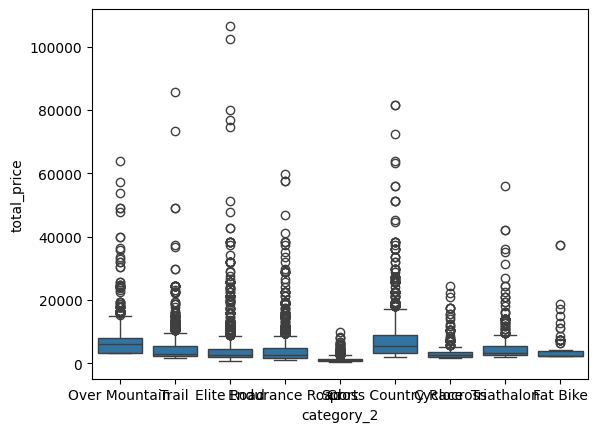

In [ ]:
import matplotlib as plt
import seaborn as sns

sns.boxplot(x='category_2', y='total_price', data=short_df)

In [ ]:
# One-hot encode categorical variables for exploratory correlation analysis
new_df = pd.get_dummies(
    short_df,
    drop_first=False,
    dtype=int
)

# Display only a small preview rather than the complete encoded dataframe
display(new_df.head())

print(
    f"Encoded dataset shape: "
    f"{new_df.shape[0]:,} rows × {new_df.shape[1]:,} columns"
)

,quantity,total_price,model_Bad Habit 1,model_Bad Habit 2,model_Beast of the East 1,model_Beast of the East 2,model_Beast of the East 3,model_CAAD Disc Ultegra,model_CAAD12 105,model_CAAD12 Black Inc,...,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_TN,state_TX,state_WA
1,1,6070,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,1,5970,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,1,2770,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,5970,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,10660,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Encoded dataset shape: 15,644 rows × 163 columns


### Exploratory Feature Relationships

The following correlations provide an initial indication of relationships
between individual features and `total_price`.

Because categorical variables have been one-hot encoded, these correlations
should be interpreted as exploratory associations rather than causal effects.

In [ ]:
# Calculate the correlation of each encoded feature with total order value
corr_series = (
    new_df
    .corrwith(new_df["total_price"])
    .drop("total_price")
    .dropna()
)

corr_df = (
    corr_series
    .to_frame(name="Correlation with total_price")
)

print(f"Number of features analysed: {len(corr_df)}")

Number of features analysed: 162


In [ ]:
# Sort correlations from the strongest positive to the strongest negative
sorted_corr_df = corr_df.sort_values(
    by="Correlation with total_price",
    ascending=False
)

strongest_positive = sorted_corr_df.head(10)

strongest_negative = sorted_corr_df.tail(10).sort_values(
    by="Correlation with total_price",
    ascending=True
)

print("Strongest positive relationships")
display(strongest_positive)

print("\nStrongest negative relationships")
display(strongest_negative)

Strongest positive relationships


,Correlation with total_price
quantity,0.601434
frame_material_Carbon,0.375966
model_Supersix Evo Black Inc.,0.204883
model_Scalpel-Si Black Inc.,0.203123
category_2_Cross Country Race,0.200144
model_Habit Hi-Mod Black Inc.,0.190538
model_F-Si Black Inc.,0.167465
model_Supersix Evo Hi-Mod Team,0.167208
model_Scalpel-Si Race,0.142527
model_Synapse Hi-Mod Disc Black Inc.,0.135179



Strongest negative relationships


,Correlation with total_price
frame_material_Aluminum,-0.375966
category_2_Sport,-0.230877
model_Catalyst 4,-0.086089
model_Catalyst 3,-0.082060
model_Catalyst 2,-0.080813
model_Trail 5,-0.077063
model_Catalyst 1,-0.072562
model_CAAD8 Claris,-0.072141
model_Synapse Claris,-0.071924
model_Synapse Sora,-0.069009


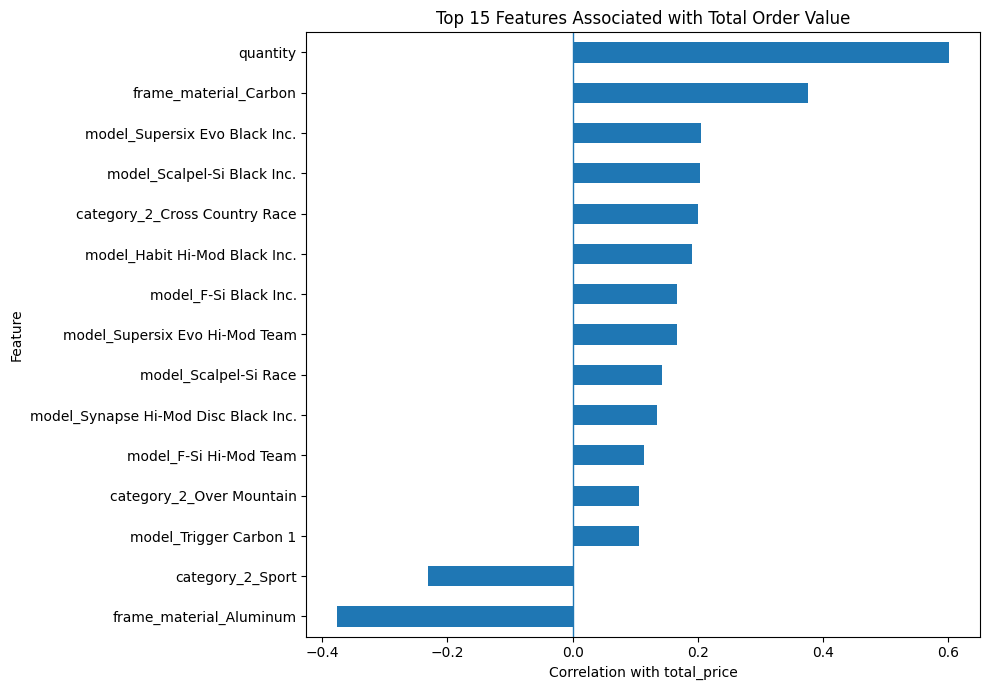

In [ ]:
import matplotlib.pyplot as plt

# Select the 15 features with the largest absolute correlations
top_15_features = (
    corr_series
    .loc[corr_series.abs().nlargest(15).index]
    .sort_values()
)

ax = top_15_features.plot(
    kind="barh",
    figsize=(10, 7)
)

ax.axvline(
    x=0,
    linewidth=1
)

ax.set_title(
    "Top 15 Features Associated with Total Order Value"
)

ax.set_xlabel(
    "Correlation with total_price"
)

ax.set_ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

## Assumption of Linear Regression

# Ordinary Least-Squares Regression and Assumption Diagnostics

An ordinary least-squares model is fitted to the complete dataset as an
interpretable statistical benchmark and to examine regression assumptions.

Because several categorical predictors contain overlapping information, the
model is used primarily for overall fit and residual diagnostics. Individual
coefficients should not be interpreted as stable independent effects.

In [ ]:
ols_formula = (
    "total_price ~ quantity + model + category_1 + category_2 "
    "+ frame_material + city + state"
)

ols_formula

'total_price ~ quantity + model + category_1 + category_2 + frame_material + city + state'

## Multiple Linear Regression

In [ ]:
from statsmodels.formula.api import ols

# Fit OLS to the complete dataset
ols_all = ols(
    formula=ols_formula,
    data=short_df
).fit()

print(ols_all.summary())

                            OLS Regression Results                            
Dep. Variable:            total_price   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     490.7
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:17:10   Log-Likelihood:            -1.4346e+05
No. Observations:               15644   AIC:                         2.872e+05
Df Residuals:                   15517   BIC:                         2.882e+05
Df Model:                         126                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

## Model Assumption: Linearity

There is no need to check the linearity assumption for categorical independent variables in multiple regression analysis. The model can still learn the relationships between the independent variables and the dependent variable, even if the relationships are not linear.

## Model assumption: Normality

In [ ]:
import pandas as pd
import numpy as np
#import datetime
import matplotlib.pyplot as plt
#from pandas.core import groupby
from pandas.core.frame import DataFrame
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import sklearn

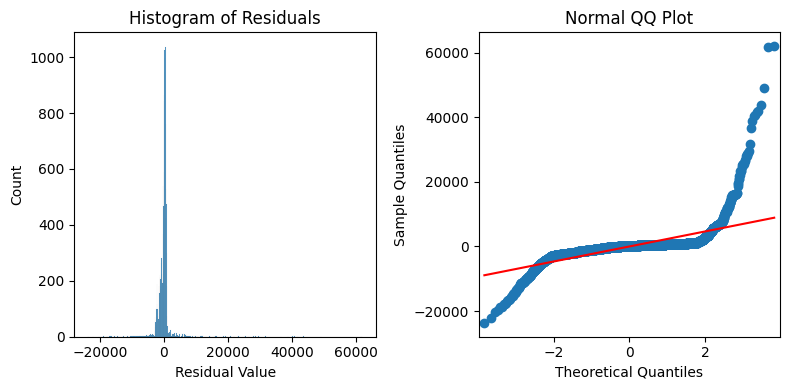

In [ ]:
# Calculate the residuals.
residuals = ols_all.resid

# Create a 1x2 plot figure.
fig, axes = plt.subplots(1, 2, figsize = (8,4))

# Create a histogram with the residuals.
sns.histplot(residuals, ax=axes[0])

# Set the x label of the residual plot.
axes[0].set_xlabel("Residual Value")

# Set the title of the residual plot.
axes[0].set_title("Histogram of Residuals")

# Create a Q-Q plot of the residuals.
sm.qqplot(residuals, line='s',ax = axes[1])

# Set the title of the Q-Q plot.
axes[1].set_title("Normal QQ Plot")

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance.
plt.tight_layout()

# Show the plot.
plt.show()

## Model assumption: Constant variance

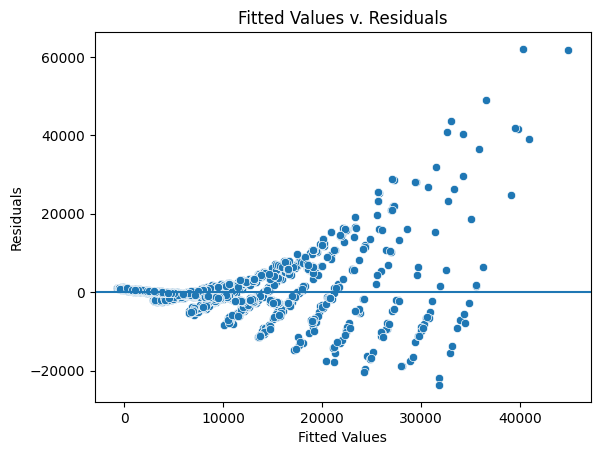

In [ ]:
# Create a scatterplot with the fitted values from the model and the residuals.

fig = sns.scatterplot(x = ols_all.fittedvalues, y = ols_all.resid)

# Set the x axis label.
fig.set_xlabel("Fitted Values")

# Set the y axis label.
fig.set_ylabel("Residuals")

# Set the title.
fig.set_title("Fitted Values v. Residuals")

# Add a line at y = 0 to visualize the variance of residuals above and below 0.

fig.axhline(0)

# Show the plot.
plt.show()

In [ ]:
import numpy as np
import pandas as pd


def create_iqr_sensitivity_dataset(
    df,
    target="total_price",
    multiplier=1.5
):
    """
    Create an IQR-filtered sensitivity dataset without modifying
    the original dataframe.

    Parameters
    ----------
    df : pandas.DataFrame
        Original modelling dataset.

    target : str, default="total_price"
        Target variable used to calculate the IQR boundaries.

    multiplier : float, default=1.5
        IQR multiplier used to define the lower and upper boundaries.

    Returns
    -------
    filtered_df : pandas.DataFrame
        Copy of the data containing observations within the IQR boundaries.

    comparison_summary : pandas.DataFrame
        Two-row table comparing the complete dataset with the filtered
        sensitivity dataset.
    """

    # Basic validation
    if target not in df.columns:
        raise KeyError(
            f"Target column '{target}' was not found in the dataframe."
        )

    if df.empty:
        raise ValueError("The dataframe is empty.")

    if multiplier <= 0:
        raise ValueError("The IQR multiplier must be greater than zero.")

    if not pd.api.types.is_numeric_dtype(df[target]):
        raise TypeError(
            f"Target column '{target}' must contain numeric values."
        )

    if df[target].isna().any():
        raise ValueError(
            f"Target column '{target}' contains missing values."
        )

    # Calculate IQR boundaries
    q1 = df[target].quantile(0.25)
    q3 = df[target].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr

    # Keep observations within the IQR boundaries
    keep_mask = df[target].between(
        lower_bound,
        upper_bound,
        inclusive="both"
    )

    # Create a new dataframe; the original is not modified
    filtered_df = df.loc[keep_mask].copy()

    rows_original = len(df)
    rows_remaining = len(filtered_df)
    rows_excluded = rows_original - rows_remaining
    percent_excluded = (
        rows_excluded / rows_original * 100
    )

    # Two-row comparison table
    comparison_summary = pd.DataFrame([
        {
            "Dataset": "All observations",
            "IQR Multiplier": "None",
            "Lower Bound": np.nan,
            "Upper Bound": np.nan,
            "Original Rows": rows_original,
            "Remaining Rows": rows_original,
            "Rows Excluded": 0,
            "% Excluded": 0.0
        },
        {
            "Dataset": f"{multiplier}×IQR sensitivity dataset",
            "IQR Multiplier": multiplier,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Original Rows": rows_original,
            "Remaining Rows": rows_remaining,
            "Rows Excluded": rows_excluded,
            "% Excluded": percent_excluded
        }
    ])

    return filtered_df, comparison_summary


# ---------------------------------------------------------
# Create the two modelling datasets
# ---------------------------------------------------------

# Primary population: all legitimate observations
data_all = short_df.copy()

# Secondary population: conventional 1.5×IQR sensitivity dataset
data_iqr, dataset_comparison = create_iqr_sensitivity_dataset(
    data_all,
    target="total_price",
    multiplier=1.5
)


# ---------------------------------------------------------
# Display the comparison
# ---------------------------------------------------------

display(
    dataset_comparison.round({
        "Lower Bound": 2,
        "Upper Bound": 2,
        "% Excluded": 2
    })
)

print(f"All observations: {len(data_all):,}")
print(f"1.5×IQR observations: {len(data_iqr):,}")
print(
    f"Observations excluded: "
    f"{len(data_all) - len(data_iqr):,}"
)

,Dataset,IQR Multiplier,Lower Bound,Upper Bound,Original Rows,Remaining Rows,Rows Excluded,% Excluded
0,All observations,None,NaN,NaN,15644,15644,0,0.00
1,1.5×IQR sensitivity dataset,1.5,-3120.0,10400.0,15644,14310,1334,8.53


All observations: 15,644
1.5×IQR observations: 14,310
Observations excluded: 1,334


### Outlier Sensitivity Datasets

The complete dataset contains 15,644 observations and is retained as the
primary modelling population.

Applying the conventional 1.5×IQR threshold produces a secondary sensitivity
dataset containing 14,310 observations. This excludes 1,334 observations,
representing approximately 8.53% of the original data.

The calculated lower boundary is negative, so no realistic low-value orders
are excluded. The filtered observations are therefore drawn from the upper
tail of the order-value distribution, where `total_price` exceeds 10,400.

Because these high-value observations may represent legitimate premium or
high-quantity orders, the filtered dataset is used only to assess the
sensitivity of model performance and model ranking. The complete dataset
remains the primary basis for final model selection.

<Axes: ylabel='total_price'>

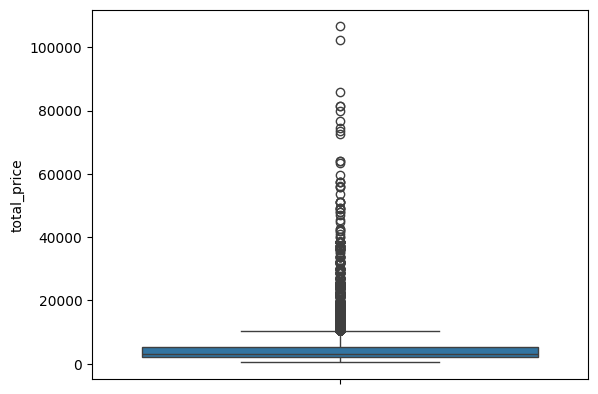

In [ ]:
# before outlier removal
sns.boxplot( y='total_price', data = data_all )

<Axes: ylabel='total_price'>

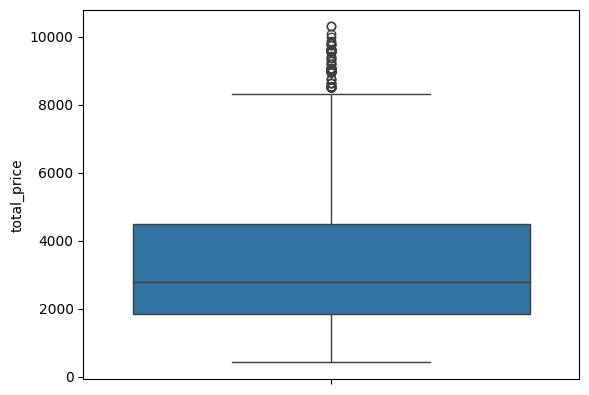

In [ ]:
#after outlier removal
sns.boxplot( y='total_price', data= data_iqr)

## Model assumption: No multicollinearity

In [ ]:
X = data_all.drop(columns=['total_price'])
X

,model,quantity,category_1,category_2,frame_material,city,state
1,Jekyll Carbon 2,1,Mountain,Over Mountain,Carbon,Ithaca,NY
2,Trigger Carbon 2,1,Mountain,Over Mountain,Carbon,Ithaca,NY
3,Beast of the East 1,1,Mountain,Trail,Aluminum,Kansas City,KS
4,Trigger Carbon 2,1,Mountain,Over Mountain,Carbon,Kansas City,KS
5,Supersix Evo Hi-Mod Team,1,Road,Elite Road,Carbon,Louisville,KY
...,...,...,...,...,...,...,...
15640,CAAD Disc Ultegra,1,Road,Elite Road,Aluminum,Austin,TX
15641,Trail 2,1,Mountain,Sport,Aluminum,Austin,TX
15642,CAAD12 105,1,Road,Elite Road,Aluminum,Austin,TX
15643,F-Si Carbon 4,1,Mountain,Cross Country Race,Carbon,Austin,TX


In [ ]:
X_dummy = pd.get_dummies(X, drop_first=True)
X_dummy

,quantity,model_Bad Habit 2,model_Beast of the East 1,model_Beast of the East 2,model_Beast of the East 3,model_CAAD Disc Ultegra,model_CAAD12 105,model_CAAD12 Black Inc,model_CAAD12 Disc 105,model_CAAD12 Disc Dura Ace,...,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_TN,state_TX,state_WA
1,1,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,1,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,1,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15640,1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
15641,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
15642,1,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
15643,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

In [ ]:
vif['Features'] = X_dummy.columns
vif['Features']

,Features
0,quantity
1,model_Bad Habit 2
2,model_Beast of the East 1
3,model_Beast of the East 2
4,model_Beast of the East 3
...,...
151,state_PA
152,state_RI
153,state_TN
154,state_TX


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Make sure all predictors are numeric
X_vif = X_dummy.astype(float)

# Optional safety check
print(X_vif.dtypes.value_counts())

vif = pd.DataFrame()
vif["feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

float64    156
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
8,model_CAAD12 Disc 105,inf
7,model_CAAD12 Black Inc,inf
6,model_CAAD12 105,inf
5,model_CAAD Disc Ultegra,inf
10,model_CAAD12 Red,inf
...,...,...
1,model_Bad Habit 2,1.823843
4,model_Beast of the East 3,1.817577
30,model_Habit 4,1.805090
32,model_Habit 6,1.766819


In [ ]:
high_vif = vif[vif["VIF"] > 5]

print(f"Total predictors: {len(vif)}")
print(f"Predictors with VIF > 5: {len(high_vif)}")
print(f"Predictors with VIF <= 5: {(vif['VIF'] <= 5).sum()}")
print(f"Predictors with infinite VIF: {np.isinf(vif['VIF']).sum()}")

Total predictors: 156
Predictors with VIF > 5: 148
Predictors with VIF <= 5: 8
Predictors with infinite VIF: 148


In [ ]:
high_vif.sort_values(
    "VIF",
    ascending=False
).head(10)

,feature,VIF
5,model_CAAD Disc Ultegra,inf
6,model_CAAD12 105,inf
7,model_CAAD12 Black Inc,inf
8,model_CAAD12 Disc 105,inf
9,model_CAAD12 Disc Dura Ace,inf
10,model_CAAD12 Red,inf
11,model_CAAD12 Ultegra,inf
12,model_CAAD8 105,inf
13,model_CAAD8 Claris,inf
14,model_CAAD8 Sora,inf


### Multicollinearity Assessment

VIF analysis indicates substantial multicollinearity among the predictors. Of the 156 encoded features, 148 have VIF values above 5, and all 148 have infinite VIF values, indicating exact linear relationships among several predictors.

This is consistent with the structure of the dataset. Several categorical variables contain overlapping information. For example, geographic variables such as city and state are related, while bike model, product category, and frame material describe overlapping product characteristics.

Because severe multicollinearity can make ordinary least-squares coefficient estimates unstable and difficult to interpret, the predictors will not be removed solely on the basis of VIF. Instead, regularised regression models such as Ridge and Lasso will be evaluated alongside other machine-learning algorithms using cross-validation and hold-out test performance.



In [ ]:
data_all_filter_log = data_all.copy()

data_all_filter_log['log_total_price'] = np.log(
    data_all_filter_log['total_price']
)

data_all_filter_log.head()

,model,quantity,total_price,category_1,category_2,frame_material,city,state,log_total_price
1,Jekyll Carbon 2,1,6070,Mountain,Over Mountain,Carbon,Ithaca,NY,8.711114
2,Trigger Carbon 2,1,5970,Mountain,Over Mountain,Carbon,Ithaca,NY,8.694502
3,Beast of the East 1,1,2770,Mountain,Trail,Aluminum,Kansas City,KS,7.926603
4,Trigger Carbon 2,1,5970,Mountain,Over Mountain,Carbon,Kansas City,KS,8.694502
5,Supersix Evo Hi-Mod Team,1,10660,Road,Elite Road,Carbon,Louisville,KY,9.274254


/tmp/ipykernel_2387/2062720261.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_all_filter_log['total_price'], fit=norm)


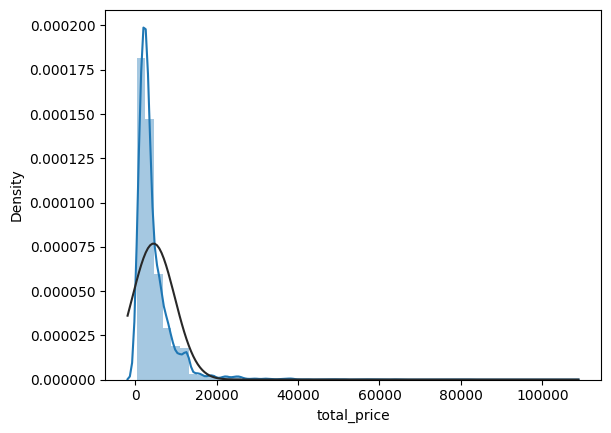

<Figure size 640x480 with 0 Axes>

In [ ]:
# before log transformation
from scipy.stats import norm
sns.distplot(data_all_filter_log['total_price'], fit=norm)
fig = plt.figure()

/tmp/ipykernel_2387/2736415363.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_all_filter_log['log_total_price'], fit=norm)


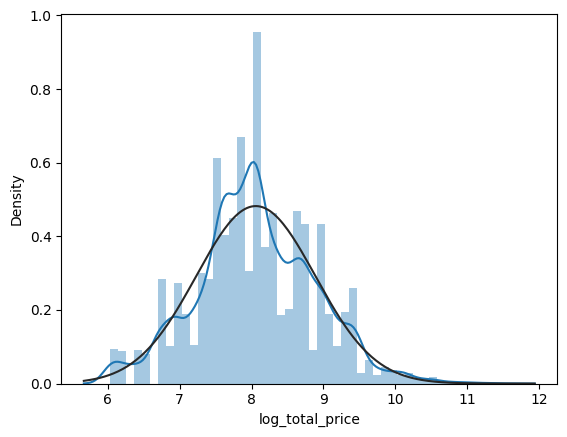

<Figure size 640x480 with 0 Axes>

In [ ]:
# after log transformation
from scipy.stats import norm
sns.distplot(data_all_filter_log['log_total_price'], fit=norm)
fig = plt.figure()

In [ ]:
from statsmodels.formula.api import ols
ols_formula_log_no_outlier =  "log_total_price  ~ model + quantity + category_1 + category_2 + frame_material + city + state "
ols_formula_log_no_outlier

OLSL_final_prep_df = ols(formula = ols_formula_log_no_outlier, data = data_all_filter_log)
Lm_model_final_prep_df = OLSL_final_prep_df.fit()

In [ ]:
print(Lm_model_final_prep_df.summary())

                            OLS Regression Results                            
Dep. Variable:        log_total_price   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     5422.
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:23:50   Log-Likelihood:                 10547.
No. Observations:               15644   AIC:                        -2.084e+04
Df Residuals:                   15517   BIC:                        -1.987e+04
Df Model:                         126                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

### Log-Transformation Assessment

The log-transformed model provides a stronger fit on the logarithmic target
scale. However, its R² is not directly comparable with the R² of a model
trained on the original `total_price` scale.

A valid predictive comparison would require transforming predictions back to
the original order-value scale and calculating RMSE and MAE against the
original target. The log analysis is therefore treated as a diagnostic
experiment rather than proof of superior final-model performance.

## Model assumption: Normality

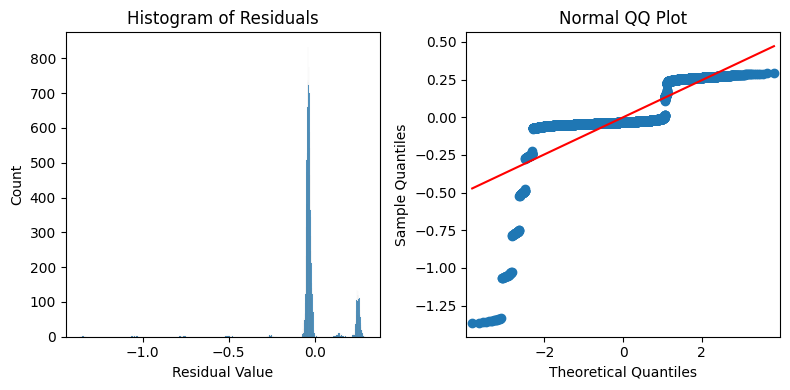

In [ ]:
# Calculate the residuals.
residuals_no_outlier = Lm_model_final_prep_df.resid

# Create a 1x2 plot figure.
fig, axes = plt.subplots(1, 2, figsize = (8,4))

# Create a histogram with the residuals.
sns.histplot(residuals_no_outlier, ax=axes[0])

# Set the x label of the residual plot.
axes[0].set_xlabel("Residual Value")

# Set the title of the residual plot.
axes[0].set_title("Histogram of Residuals")

# Create a Q-Q plot of the residuals.
sm.qqplot(residuals_no_outlier, line='s',ax = axes[1])

# Set the title of the Q-Q plot.
axes[1].set_title("Normal QQ Plot")

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance.
plt.tight_layout()

# Show the plot.
plt.show()

## Model assumption: Constant variance

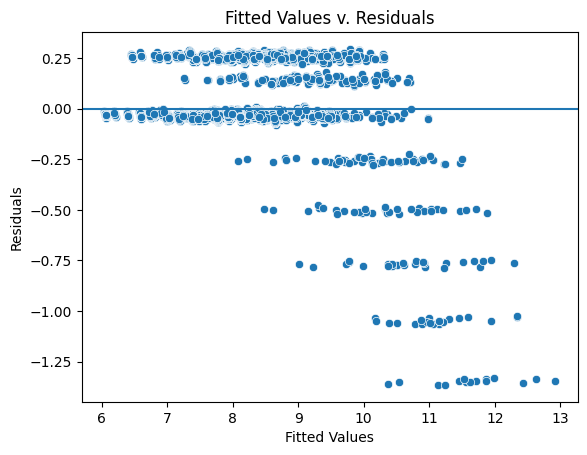

In [ ]:
# Create a scatterplot with the fitted values from the model and the residuals.

fig = sns.scatterplot(x = Lm_model_final_prep_df.fittedvalues, y = Lm_model_final_prep_df.resid)

# Set the x axis label.
fig.set_xlabel("Fitted Values")

# Set the y axis label.
fig.set_ylabel("Residuals")

# Set the title.
fig.set_title("Fitted Values v. Residuals")

# Add a line at y = 0 to visualize the variance of residuals above and below 0.

fig.axhline(0)

# Show the plot.
plt.show()

The residual diagnostics indicate that the assumptions of ordinary
least-squares regression are not fully satisfied. The analysis therefore
continues with regularised linear models and non-linear algorithms evaluated
using hold-out testing and cross-validation.

# Baseline and Linear Regression Benchmark

A naive baseline model is established before comparing more advanced
machine-learning algorithms. The baseline predicts the mean training-set
order value for every observation.

Linear Regression is then evaluated using the same train/test split and
preprocessing procedure. A useful predictive model should materially
outperform the baseline.

The comparison is performed separately for:

1. The complete dataset, which represents the primary business population.
2. The 1.5×IQR dataset, which is used only as a sensitivity analysis.

Categorical encoding is learned from the training data only to avoid
information leakage. Because filtering changes the distribution and range of
the target variable, metrics from the two datasets should not be treated as a
direct like-for-like comparison.

In [ ]:
# Imports and model configuration
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


# ---------------------------------------------------------
# Modelling configuration
# ---------------------------------------------------------

TARGET = "total_price"

# Quantity is the only numeric predictor in the selected dataset
NUMERIC_FEATURES = [
    "quantity"
]

# Product and geographic variables are categorical
CATEGORICAL_FEATURES = [
    "model",
    "category_1",
    "category_2",
    "frame_material",
    "city",
    "state"
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

In [ ]:
# Build the preprocessing and modelling pipeline
def build_benchmark_pipeline(estimator):
    """
    Create a preprocessing and modelling pipeline.

    Numeric missing values are replaced with the median.
    Categorical missing values are replaced with the most frequent value.
    One-hot encoding is learned from the training data only.

    Parameters
    ----------
    estimator : sklearn-compatible estimator
        Regression model to be added to the pipeline.

    Returns
    -------
    sklearn.pipeline.Pipeline
        Complete preprocessing and modelling pipeline.
    """

    # Numeric preprocessing
    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ])

    # Categorical preprocessing
    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            )
        )
    ])

    # Apply the correct preprocessing to each feature type
    preprocessor = ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES
        )
    ])

    # Combine preprocessing and model fitting
    pipeline = Pipeline([
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            estimator
        )
    ])

    return pipeline

In [ ]:
# 4. Evaluation function
def evaluate_benchmark_models(
    data,
    dataset_name,
    test_size=0.30,
    random_state=42
):
    """
    Evaluate a mean baseline and Linear Regression using the
    same train/test split.

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset used for modelling.

    dataset_name : str
        Descriptive name shown in the results table.

    test_size : float, default=0.30
        Proportion of observations reserved for testing.

    random_state : int, default=42
        Seed used to make the train/test split reproducible.

    Returns
    -------
    results_df : pandas.DataFrame
        Evaluation metrics for both models.

    fitted_models : dict
        Fitted sklearn pipelines.

    prediction_tables : dict
        Actual and predicted values for each model.

    X_test : pandas.DataFrame
        Test-set predictors.

    y_test : pandas.Series
        Test-set target values.
    """

    # Confirm that the required columns exist
    required_columns = FEATURES + [TARGET]

    missing_columns = [
        column
        for column in required_columns
        if column not in data.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing required columns: {missing_columns}"
        )

    # Select only the variables used in this analysis
    modelling_data = data[required_columns].copy()

    # Remove observations with a missing target
    modelling_data = modelling_data.dropna(
        subset=[TARGET]
    )

    X = modelling_data[FEATURES]
    y = modelling_data[TARGET]

    # Use one shared split for both models
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )

    # Mean Baseline:
    # predicts the training-set mean for every test observation
    #
    # Linear Regression:
    # estimates order value using all selected predictors
    candidate_models = {
        "Mean Baseline": DummyRegressor(
            strategy="mean"
        ),
        "Linear Regression": LinearRegression()
    }

    result_rows = []
    fitted_models = {}
    prediction_tables = {}

    for model_name, estimator in candidate_models.items():

        # Build a fresh preprocessing pipeline for each model
        pipeline = build_benchmark_pipeline(
            estimator
        )

        # Learn preprocessing and model parameters using training data
        pipeline.fit(
            X_train,
            y_train
        )

        # Generate predictions for the untouched test set
        predictions = pipeline.predict(
            X_test
        )

        # Calculate model-performance metrics
        r_squared = r2_score(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        mean_test_value = y_test.mean()

        mae_percentage = (
            mae / mean_test_value * 100
            if mean_test_value != 0
            else np.nan
        )

        result_rows.append({
            "Dataset": dataset_name,
            "Model": model_name,
            "Training Rows": len(X_train),
            "Test Rows": len(X_test),
            "R²": r_squared,
            "RMSE": rmse,
            "MAE": mae,
            "Mean Test Order Value": mean_test_value,
            "MAE (% of Mean Test Value)": mae_percentage
        })

        # Save fitted model for later analysis
        fitted_models[model_name] = pipeline

        # Save predictions for later charts or error analysis
        prediction_tables[model_name] = pd.DataFrame({
            "Actual": y_test,
            "Predicted": predictions,
            "Residual": y_test - predictions
        })

    results_df = pd.DataFrame(
        result_rows
    )

    return (
        results_df,
        fitted_models,
        prediction_tables,
        X_test,
        y_test
    )

Benchmark Evaluation on Both Datasets

In [ ]:
# Benchmark Evaluation on Both Datasets
# ---------------------------------------------------------
# Experiment 1: complete dataset
# ---------------------------------------------------------

(
    benchmark_all,
    models_all,
    predictions_all,
    X_test_all,
    y_test_all
) = evaluate_benchmark_models(
    data=data_all,
    dataset_name="All observations"
)


# ---------------------------------------------------------
# Experiment 2: 1.5×IQR sensitivity dataset
# ---------------------------------------------------------

(
    benchmark_iqr,
    models_iqr,
    predictions_iqr,
    X_test_iqr,
    y_test_iqr
) = evaluate_benchmark_models(
    data=data_iqr,
    dataset_name="1.5 × IQR sensitivity"
)


# Combine results from both experiments
benchmark_results = pd.concat(
    [
        benchmark_all,
        benchmark_iqr
    ],
    ignore_index=True
)

In [ ]:
# 6. Calculate improvement over the baseline
# Retrieve the baseline RMSE separately for each dataset
baseline_rmse = (
    benchmark_results[
        benchmark_results["Model"] == "Mean Baseline"
    ]
    .set_index("Dataset")["RMSE"]
)

# Calculate the percentage reduction in RMSE relative to
# the corresponding baseline model
benchmark_results["RMSE Improvement vs Baseline (%)"] = (
    benchmark_results.apply(
        lambda row: (
            (
                baseline_rmse.loc[row["Dataset"]]
                - row["RMSE"]
            )
            / baseline_rmse.loc[row["Dataset"]]
            * 100
        ),
        axis=1
    )
)


# Put datasets and models into a logical display order
dataset_order = {
    "All observations": 1,
    "1.5 × IQR sensitivity": 2
}

model_order = {
    "Mean Baseline": 1,
    "Linear Regression": 2
}

benchmark_results["Dataset Order"] = (
    benchmark_results["Dataset"].map(
        dataset_order
    )
)

benchmark_results["Model Order"] = (
    benchmark_results["Model"].map(
        model_order
    )
)

benchmark_results = (
    benchmark_results
    .sort_values(
        by=[
            "Dataset Order",
            "Model Order"
        ]
    )
    .drop(
        columns=[
            "Dataset Order",
            "Model Order"
        ]
    )
    .reset_index(drop=True)
)

In [ ]:
# 7. Display the final benchmark table
benchmark_display = benchmark_results.copy()

# Replace extremely small R² values with zero for presentation
benchmark_display.loc[
    benchmark_display["R²"].abs() < 0.0005,
    "R²"
] = 0.0

benchmark_columns = [
    "Dataset",
    "Model",
    "Training Rows",
    "Test Rows",
    "R²",
    "RMSE",
    "MAE",
    "MAE (% of Mean Test Value)",
    "RMSE Improvement vs Baseline (%)"
]

display(
    benchmark_display[
        benchmark_columns
    ]
    .style
    .format({
        "Training Rows": "{:,.0f}",
        "Test Rows": "{:,.0f}",
        "R²": "{:.3f}",
        "RMSE": "{:,.2f}",
        "MAE": "{:,.2f}",
        "MAE (% of Mean Test Value)": "{:.2f}%",
        "RMSE Improvement vs Baseline (%)": "{:.2f}%"
    })
    .hide(axis="index")
)


Dataset,Model,Training Rows,Test Rows,R²,RMSE,MAE,MAE (% of Mean Test Value),RMSE Improvement vs Baseline (%)
All observations,Mean Baseline,"10,950","4,694",0.000,"5,177.16","3,038.27",67.15%,0.00%
All observations,Linear Regression,"10,950","4,694",0.810,"2,257.38",939.96,20.78%,56.40%
1.5 × IQR sensitivity,Mean Baseline,"10,017","4,293",0.000,"2,216.11","1,759.48",52.14%,0.00%
1.5 × IQR sensitivity,Linear Regression,"10,017","4,293",0.939,548.89,264.86,7.85%,75.23%


## Benchmark Results

Linear Regression materially outperforms the mean baseline in both modelling
populations.

On the complete dataset, Linear Regression achieved an R² of 0.810, indicating
that the selected product, quantity and geographic predictors explain
approximately 81% of the variation in total order value. The model reduced
RMSE by approximately 56.4% relative to the mean baseline. Its average absolute
prediction error was approximately 940 order-value units.

On the 1.5×IQR sensitivity dataset, Linear Regression achieved an R² of 0.939
and reduced RMSE by approximately 75.2% relative to the corresponding baseline.
The average absolute prediction error decreased to approximately 265
order-value units.

The stronger metrics on the filtered dataset should be interpreted cautiously.
The 1.5×IQR dataset excludes 1,334 high-value observations and has a narrower
target distribution. Its RMSE and MAE are therefore not directly comparable
with the errors obtained from the complete dataset.

The complete dataset remains the primary basis for final model selection
because it represents the full business population. The filtered dataset is
retained only to assess whether model performance and model ranking are
sensitive to extreme order values.

# Automated Model Comparison with PyCaret

PyCaret is used to compare multiple regression algorithms under a consistent
cross-validation framework.

Two independent experiments are run:

1. The complete dataset, which represents the primary business population.
2. The 1.5×IQR dataset, which is used only as a sensitivity analysis.

The principal model-selection decision will be based on the complete dataset.
The filtered experiment will show whether model ranking is sensitive to
extreme order values.

In [ ]:
#!pip install -q --pre pycaret==4.0.0a8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.8/831.8 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.39.0 which is incompatible.


In [ ]:
import pycaret
pycaret.__version__

'4.0.0a8'

In [ ]:
from pycaret.tasks import RegressionExperiment


# ---------------------------------------------------------
# PyCaret experiment: all observations
# ---------------------------------------------------------

# Cross-validation is configured when the experiment is created.
# train_size=0.70 also aligns the holdout proportion with the
# earlier sklearn benchmark, which used a 70/30 split.
exp_all = RegressionExperiment(
    target="total_price",
    session_id=42,
    train_size=0.70,
    fold=5,
    fold_strategy="kfold"
).fit(data_all)


# ---------------------------------------------------------
# First test one model
# ---------------------------------------------------------

# errors="raise" is used during testing so that PyCaret shows
# the underlying exception instead of silently skipping a model.
result_lr_test = exp_all.compare_models(
    include=["lr"],
    sort="RMSE",
    errors="raise",
    verbose=True
)


print("Linear Regression — all observations")

display(
    result_lr_test.leaderboard
    .reset_index()
)

Linear Regression — all observations


,index,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,0,lr,2085.3423,1.291805e+07,3585.0601,0.5186,0.8773,0.0


In [ ]:
print(
    "Leaderboard shape:",
    result_lr_test.leaderboard.shape
)

print(
    "Best model available:",
    result_lr_test.best is not None
)

print(
    "Ranked model IDs:",
    result_lr_test.ranked_ids
)

Leaderboard shape: (1, 7)
Best model available: True
Ranked model IDs: ['lr']


In [ ]:
# ---------------------------------------------------------
# Compare available regression models: all observations
# ---------------------------------------------------------

result_all = exp_all.compare_models(
    sort="RMSE",
    n_select=5,
    errors="ignore",
    verbose=True
)


if result_all.leaderboard.empty:
    raise RuntimeError(
        "No models completed successfully in the all-data experiment."
    )


best_model_all = result_all.best

leaderboard_all = (
    result_all.leaderboard
    .reset_index()
    .copy()
)


print("Top models — all observations")

display(
    leaderboard_all.head(10)
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set: 8760, number of used features: 7
[LightGBM] [Info] Start training from score 4520.668950
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000884 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set: 8760, number of used features: 7
[LightGBM] [Info] Start training from score 4508.003425
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000928 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set:

,index,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,0,xgboost,165.2279,2.321953e+06,1457.9885,0.9189,0.0566,0.0
1,1,rf,246.6767,3.713002e+06,1882.3578,0.8675,0.0796,0.0
2,2,lightgbm,399.9699,3.818321e+06,1906.5675,0.8634,0.1151,0.0
3,3,et,283.5570,4.296868e+06,2053.6806,0.8425,0.0881,0.0
4,4,dt,224.2311,4.711548e+06,2106.5034,0.8309,0.0884,0.0
5,5,gbr,931.0415,4.775047e+06,2170.9556,0.8243,0.2607,0.0
6,6,knn,1186.7526,1.230899e+07,3487.0960,0.5476,0.3576,0.0
7,7,kr,2081.5188,1.290934e+07,3583.8269,0.5189,0.9258,0.0
8,8,br,2084.2907,1.291802e+07,3585.0436,0.5186,0.8802,0.0
9,9,lasso,2084.5396,1.291807e+07,3585.0504,0.5186,0.8807,0.0


In [ ]:
# ---------------------------------------------------------
# PyCaret experiment: 1.5 × IQR sensitivity dataset
# ---------------------------------------------------------

exp_iqr = RegressionExperiment(
    target="total_price",
    session_id=42,
    train_size=0.70,
    fold=5,
    fold_strategy="kfold"
).fit(data_iqr)

In [ ]:
# ---------------------------------------------------------
# Compare available regression models: 1.5 × IQR dataset
# ---------------------------------------------------------

result_iqr = exp_iqr.compare_models(
    sort="RMSE",
    n_select=5,
    errors="ignore",
    verbose=True
)


if result_iqr.leaderboard.empty:
    raise RuntimeError(
        "No models completed successfully in the IQR experiment."
    )


best_model_iqr = result_iqr.best

leaderboard_iqr = (
    result_iqr.leaderboard
    .reset_index()
    .copy()
)


print("Top models — 1.5 × IQR sensitivity dataset")

display(
    leaderboard_iqr.head(10)
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000852 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 165
[LightGBM] [Info] Number of data points in the train set: 8013, number of used features: 7
[LightGBM] [Info] Start training from score 3402.417322
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 166
[LightGBM] [Info] Number of data points in the train set: 8013, number of used features: 7
[LightGBM] [Info] Start training from score 3409.450268
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000836 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 166
[LightGBM] [Info] Number of data points in the train set:

,index,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,0,xgboost,19.4607,1.546059e+04,122.4812,0.9967,0.0202,0.0
1,1,et,24.0742,2.521008e+04,156.3410,0.9946,0.0259,0.0
2,2,rf,23.4979,3.273894e+04,177.9038,0.9931,0.0289,0.0
3,3,dt,17.9644,4.487864e+04,207.7631,0.9905,0.0356,0.0
4,4,lightgbm,84.7643,5.310035e+04,229.3098,0.9887,0.0455,0.0
5,5,gbr,524.9597,5.560213e+05,745.4887,0.8820,0.2166,0.0
6,6,knn,591.5045,1.347913e+06,1160.7690,0.7138,0.2970,0.0
7,7,ada,1334.1762,2.524482e+06,1588.7825,0.4639,0.5377,0.0
8,8,ridge,1212.6184,2.561258e+06,1600.1832,0.4564,0.5155,0.0
9,9,br,1212.5928,2.561259e+06,1600.1833,0.4564,0.5155,0.0


## Controlled Tuning and Ensemble Experiments

XGBoost achieved the strongest cross-validated performance on both the
complete and 1.5×IQR datasets.

The complete dataset remains the primary modelling population. Therefore,
additional tuning and ensemble experiments are performed only on the
complete-data experiment.

The following candidates are evaluated:

1. Original XGBoost model.
2. Tuned XGBoost model.
3. A voting blend of the three strongest models.
4. A stacked model using the three strongest models.

Bagging and boosting wrappers are not tested separately because the leading
candidate models are already tree-based ensemble algorithms.

Final model selection will be based on performance on the untouched holdout
set rather than cross-validation results alone. An ensemble will be retained
only if it produces a meaningful improvement in RMSE without materially
worsening MAE.

In [ ]:
# Confirm that compare_models returned enough models
if len(result_all.models) < 3:
    raise RuntimeError(
        "At least three fitted models are required for "
        "blending and stacking."
    )

# Models are stored in cross-validation ranking order
top3_all = list(result_all.models[:3])

print(f"Number of selected base models: {len(top3_all)}")
print("Top three leaderboard models:")

display(
    result_all.leaderboard
    .reset_index()
    .head(3)
)

Number of selected base models: 3
Top three leaderboard models:


,index,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,0,xgboost,165.2279,2.321953e+06,1457.9885,0.9189,0.0566,0.0
1,1,rf,246.6767,3.713002e+06,1882.3578,0.8675,0.0796,0.0
2,2,lightgbm,399.9699,3.818321e+06,1906.5675,0.8634,0.1151,0.0


In [ ]:
# ---------------------------------------------------------
# Hyperparameter tuning: best complete-data model
# ---------------------------------------------------------

# Start with 10 random configurations.
# Increase n_iter to 20 later only if runtime is acceptable.
tuned_xgb_all = exp_all.tune_model(
    result_all.best,
    n_iter=5,
    optimize="RMSE"
    #,search_algorithm="random"
)

print("Tuned XGBoost cross-validation metrics")

display(
    tuned_xgb_all.metrics
)

Tuned XGBoost cross-validation metrics


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold 0,243.0721,1.531712e+06,1237.6235,0.9371,0.0753,0.0
Fold 1,290.2081,4.859014e+06,2204.3171,0.8604,0.0746,0.0
Fold 2,254.3183,1.936282e+06,1391.5035,0.9139,0.0885,0.0
Fold 3,248.5213,2.035543e+06,1426.7245,0.9147,0.0793,0.0
Fold 4,288.4904,3.182934e+06,1784.0779,0.8919,0.0791,0.0
Mean,264.9220,2.709097e+06,1608.8493,0.9036,0.0793,0.0
Std,20.2667,1.206965e+06,347.4203,0.0259,0.0050,0.0


### Hyperparameter-Tuning Result

Hyperparameter tuning did not improve XGBoost performance.

The original XGBoost model achieved a cross-validated RMSE of approximately
1,458 and R² of 0.919. The tuned model produced a higher RMSE of approximately
1,609 and a lower R² of 0.904.

The tuned model also increased MAE from approximately 165 to 265. Therefore,
the original XGBoost model is retained for the subsequent ensemble experiments.

This result demonstrates that hyperparameter tuning does not automatically
improve a model and that candidate models should always be compared using the
same validation procedure.

In [ ]:
# Original XGBoost cross-validation results
original_xgb_metrics = (
    result_all.leaderboard
    .loc[
        result_all.leaderboard["Model"] == "xgboost",
        ["MAE", "MSE", "RMSE", "R2", "RMSLE"]
    ]
    .iloc[0]
)

# Tuned XGBoost mean cross-validation results
tuned_xgb_metrics = tuned_xgb_all.metrics.loc[
    "Mean",
    ["MAE", "MSE", "RMSE", "R2", "RMSLE"]
]

tuning_comparison = pd.DataFrame(
    [
        original_xgb_metrics,
        tuned_xgb_metrics
    ],
    index=[
        "Original XGBoost",
        "Tuned XGBoost"
    ]
)

tuning_comparison["RMSE Change vs Original (%)"] = (
    (
        tuning_comparison["RMSE"]
        - tuning_comparison.loc[
            "Original XGBoost",
            "RMSE"
        ]
    )
    / tuning_comparison.loc[
        "Original XGBoost",
        "RMSE"
    ]
    * 100
)

display(
    tuning_comparison
    .style
    .format({
        "MAE": "{:,.2f}",
        "MSE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.4f}",
        "RMSLE": "{:.4f}",
        "RMSE Change vs Original (%)": "{:+.2f}%"
    })
)

,MAE,MSE,RMSE,R2,RMSLE,RMSE Change vs Original (%)
Original XGBoost,165.23,"2,321,953.24","1,457.99",0.9189,0.0566,+0.00%
Tuned XGBoost,264.92,"2,709,097.02","1,608.85",0.9036,0.0793,+10.35%


In [ ]:
# Retain the original XGBoost model
selected_xgb_all = result_all.best

In [ ]:
# The models are stored in leaderboard ranking order:
# 0 = XGBoost
# 1 = Random Forest
# 2 = LightGBM

ensemble_inputs_all = list(
    result_all.models[:3]
)

print(
    f"Number of ensemble input models: "
    f"{len(ensemble_inputs_all)}"
)

display(
    result_all.leaderboard
    .reset_index()
    .head(3)
)

Number of ensemble input models: 3


,index,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,0,xgboost,165.2279,2.321953e+06,1457.9885,0.9189,0.0566,0.0
1,1,rf,246.6767,3.713002e+06,1882.3578,0.8675,0.0796,0.0
2,2,lightgbm,399.9699,3.818321e+06,1906.5675,0.8634,0.1151,0.0


In [ ]:
# The models are stored in leaderboard ranking order:
# 0 = XGBoost
# 1 = Random Forest
# 2 = LightGBM

ensemble_inputs_all = list(
    result_all.models[:3]
)

print(
    f"Number of ensemble input models: "
    f"{len(ensemble_inputs_all)}"
)

display(
    result_all.leaderboard
    .reset_index()
    .head(3)
)

Number of ensemble input models: 3


,index,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,0,xgboost,165.2279,2.321953e+06,1457.9885,0.9189,0.0566,0.0
1,1,rf,246.6767,3.713002e+06,1882.3578,0.8675,0.0796,0.0
2,2,lightgbm,399.9699,3.818321e+06,1906.5675,0.8634,0.1151,0.0


In [ ]:
# ---------------------------------------------------------
# Voting ensemble
# ---------------------------------------------------------

blend_all = exp_all.blend_models(
    ensemble_inputs_all
)

print("Voting-blend cross-validation results")

display(
    blend_all.metrics
)

Voting-blend cross-validation results


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold 0,222.2141,1.171738e+06,1082.4687,0.9518,0.0707,0.0
Fold 1,282.9747,5.555600e+06,2357.0321,0.8404,0.0695,0.0
Fold 2,234.3558,2.132688e+06,1460.3726,0.9051,0.0753,0.0
Fold 3,242.2031,2.322815e+06,1524.0785,0.9027,0.0700,0.0
Fold 4,300.1472,3.575638e+06,1890.9357,0.8786,0.0822,0.0
Mean,256.3790,2.951696e+06,1662.9775,0.8957,0.0735,0.0
Std,29.9206,1.510241e+06,431.5110,0.0364,0.0048,0.0


In [ ]:
blend_all.pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical_pipeline',
                                                  SimpleImputer(),
                                                  ['quantity']),
                                                 ('categorical_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['model', 'category_1',
                                                   'category_2',
                                                   'frame_material', 'city',
                                                   'st...
                                                           max_cat_threshold=None,
                                                           max_cat_to_onehot=None,
                                                           max_delta_step=None,
                                                           max_depth=None,
                                                           max_leaves=None,
                                                           min_child_weight=None,
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=-1,
                                                           num_parallel_tree=None, ...)),
                                             ('rf_1',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42)),
                                             ('lightgbm_2',
                                              LGBMRegressor(n_jobs=-1,
                                                            random_state=42))],
                                 n_jobs=-1))])

In [ ]:
from sklearn.linear_model import Ridge


# ---------------------------------------------------------
# Stacked ensemble
# ---------------------------------------------------------

stack_all = exp_all.stack_models(
    ensemble_inputs_all,
    meta_model=Ridge(alpha=1.0)
)

print("Stacked-model cross-validation results")

display(
    stack_all.metrics
)

Stacked-model cross-validation results


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold 0,194.5500,6.763617e+05,822.4121,0.9722,0.0685,0.0
Fold 1,196.6074,4.397727e+06,2097.0758,0.8737,0.0547,0.0
Fold 2,221.9671,1.428896e+06,1195.3645,0.9364,0.0773,0.0
Fold 3,313.8970,2.814101e+06,1677.5282,0.8821,0.0990,0.0
Fold 4,298.7837,2.943430e+06,1715.6427,0.9000,0.0874,0.0
Mean,245.1610,2.452103e+06,1501.6047,0.9129,0.0774,0.0
Std,51.1017,1.292912e+06,444.1695,0.0367,0.0152,0.0


In [ ]:
stack_all.pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical_pipeline',
                                                  SimpleImputer(),
                                                  ['quantity']),
                                                 ('categorical_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['model', 'category_1',
                                                   'category_2',
                                                   'frame_material', 'city',
                                                   'st...
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=None,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=None,
                                                             n_jobs=-1,
                                                             num_parallel_tree=None, ...)),
                                               ('rf_1',
                                                RandomForestRegressor(n_jobs=-1,
                                                                      random_state=42)),
                                               ('lightgbm_2',
                                                LGBMRegressor(n_jobs=-1,
                                                              random_state=42))],
                                   final_estimator=Ridge(), n_jobs=-1))])

In [ ]:
def extract_mean_metrics(
    metrics_df,
    candidate_name
):
    """
    Extract the Mean row from a PyCaret cross-validation table.
    """

    mean_row = metrics_df.loc[
        "Mean",
        ["MAE", "MSE", "RMSE", "R2", "RMSLE"]
    ].copy()

    mean_row.name = candidate_name

    return mean_row


original_xgb_row = (
    result_all.leaderboard
    .loc[
        result_all.leaderboard["Model"] == "xgboost",
        ["MAE", "MSE", "RMSE", "R2", "RMSLE"]
    ]
    .iloc[0]
    .rename("Original XGBoost")
)

tuned_xgb_row = extract_mean_metrics(
    tuned_xgb_all.metrics,
    "Tuned XGBoost"
)

blend_row = extract_mean_metrics(
    blend_all.metrics,
    "Top-3 Voting Blend"
)

stack_row = extract_mean_metrics(
    stack_all.metrics,
    "Top-3 Stack"
)


ensemble_cv_comparison = pd.DataFrame([
    original_xgb_row,
    tuned_xgb_row,
    blend_row,
    stack_row
])


original_rmse = ensemble_cv_comparison.loc[
    "Original XGBoost",
    "RMSE"
]

ensemble_cv_comparison[
    "RMSE Improvement vs Original XGBoost (%)"
] = (
    (
        original_rmse
        - ensemble_cv_comparison["RMSE"]
    )
    / original_rmse
    * 100
)


ensemble_cv_comparison = (
    ensemble_cv_comparison
    .sort_values(
        by="RMSE",
        ascending=True
    )
)


display(
    ensemble_cv_comparison
    .style
    .format({
        "MAE": "{:,.2f}",
        "MSE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.4f}",
        "RMSLE": "{:.4f}",
        "RMSE Improvement vs Original XGBoost (%)":
            "{:+.2f}%"
    })
)

,MAE,MSE,RMSE,R2,RMSLE,RMSE Improvement vs Original XGBoost (%)
Original XGBoost,165.23,"2,321,953.24","1,457.99",0.9189,0.0566,+0.00%
Top-3 Stack,245.16,"2,452,103.14","1,501.60",0.9129,0.0774,-2.99%
Tuned XGBoost,264.92,"2,709,097.02","1,608.85",0.9036,0.0793,-10.35%
Top-3 Voting Blend,256.38,"2,951,695.91","1,662.98",0.8957,0.0735,-14.06%


### Tuning and Ensemble Results

The original XGBoost model achieved the strongest cross-validated performance
among all evaluated candidates.

Hyperparameter tuning did not improve the model. The tuned XGBoost
configuration increased RMSE from approximately 1,458 to 1,609 and reduced
R² from 0.919 to 0.904.

The stacked ensemble was the strongest ensemble candidate, but it still
produced an RMSE approximately 3.0% higher than the original XGBoost model.
Its MAE was also substantially higher.

The equal-weight voting blend performed worse than both the original XGBoost
model and the stacked ensemble. This suggests that combining XGBoost with
weaker Random Forest and LightGBM models diluted the predictive strength of
the leading model.

Therefore, the original XGBoost model is retained as the final candidate for
holdout evaluation. Further ensemble complexity is not justified because it
does not produce an improvement in predictive performance.

MAPE is omitted from model interpretation because it is reported as 0.0 for
all candidates in the current experiment and therefore does not differentiate
their performance.

In [ ]:
# ---------------------------------------------------------
# Final candidate selected from cross-validation
# ---------------------------------------------------------

selected_model_all = result_all.best
selected_model_name = "Original XGBoost"

print(f"Selected final candidate: {selected_model_name}")

Selected final candidate: Original XGBoost


### Why XGBoost Was Selected

Model selection was based exclusively on cross-validation performance within
the training data.

Original XGBoost achieved the lowest cross-validated RMSE among the evaluated
machine-learning candidates. Hyperparameter tuning, stacking and voting did
not improve this result.

XGBoost was therefore selected before the untouched test set was examined.

The test set is used only in the following section to estimate how the
selected model performs on unseen observations.

### Model Selection Journey

The table below summarises the main modelling decisions made during the
project. Each stage was retained only when it contributed useful evidence
toward the final model-selection decision.

In [ ]:
model_selection_journey = (
    ensemble_cv_comparison[
        [
            "RMSE",
            "R2"
        ]
    ]
    .rename(columns={
        "RMSE": "CV RMSE",
        "R2": "CV R²"
    })
    .copy()
)

model_selection_journey[
    "Evaluation Method"
] = "5-fold cross-validation"

model_selection_journey[
    "Decision"
] = np.where(
    model_selection_journey.index == "Original XGBoost",
    "Selected",
    "Rejected"
)

model_selection_journey = (
    model_selection_journey
    .reset_index()
    .rename(columns={"index": "Candidate"})
)

display(
    model_selection_journey[
        [
            "Candidate",
            "Evaluation Method",
            "CV RMSE",
            "CV R²",
            "Decision"
        ]
    ]
    .style
    .format({
        "CV RMSE": "{:,.2f}",
        "CV R²": "{:.4f}"
    })
    .hide(axis="index")
)

Candidate,Evaluation Method,CV RMSE,CV R²,Decision
Original XGBoost,5-fold cross-validation,"1,457.99",0.9189,Selected
Top-3 Stack,5-fold cross-validation,"1,501.60",0.9129,Rejected
Tuned XGBoost,5-fold cross-validation,"1,608.85",0.9036,Rejected
Top-3 Voting Blend,5-fold cross-validation,"1,662.98",0.8957,Rejected


## Final Evaluation on Unseen Test Data

Cross-validation was used only for model selection.

After XGBoost was selected, its generalisation performance was evaluated once
on the untouched 30% test set. These test observations were not used during
model comparison or hyperparameter selection.

The test-set results therefore provide the primary estimate of performance on
unseen observations.

In [ ]:
xgb_holdout_all = exp_all.predict_model(
    selected_model_all
)

In [ ]:
final_holdout_metrics = xgb_holdout_all.metrics.copy()
final_holdout_metrics["Model"] = selected_model_name

display_columns = [
    column
    for column in [
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "RMSLE"
    ]
    if column in final_holdout_metrics.columns
]

display(
    final_holdout_metrics[
        display_columns
    ]
    .style
    .format({
        "MAE": "{:,.2f}",
        "MSE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R2": "{:.4f}",
        "RMSLE": "{:.4f}"
    })
    .hide(axis="index")
)

Model,MAE,MSE,RMSE,R2,RMSLE
Original XGBoost,139.43,"2,399,176.25","1,548.93",0.9105,0.0468


In [ ]:
final_predictions_all = (
    xgb_holdout_all.predictions.copy()
)

display(
    final_predictions_all.head()
)

,model,quantity,category_1,category_2,frame_material,city,state,total_price,prediction_label
6597,Synapse Carbon Ultegra 4,1,Road,Endurance Road,Carbon,Miami,FL,2660,2668.689941
4817,CAAD Disc Ultegra,1,Road,Elite Road,Aluminum,New Orleans,LA,2660,2662.906006
9351,Habit 4,1,Mountain,Trail,Aluminum,Portland,OR,2880,2863.304932
8012,CAAD12 105,1,Road,Elite Road,Aluminum,Las Vegas,NV,1680,1699.063110
7741,CAAD12 Ultegra,1,Road,Elite Road,Aluminum,New Orleans,LA,2240,2230.446533


In [ ]:
final_predictions_all[
    ["total_price", "prediction_label"]
].head(10)

,total_price,prediction_label
6597,2660,2668.689941
4817,2660,2662.906006
9351,2880,2863.304932
8012,1680,1699.063110
7741,2240,2230.446533
9510,5860,5867.112793
8701,1570,1569.885376
8889,1250,1272.272827
2609,2660,2658.206787
7633,6070,6057.694824


In [ ]:
final_error_analysis = final_predictions_all.copy()

final_error_analysis["Residual"] = (
    final_error_analysis["total_price"]
    - final_error_analysis["prediction_label"]
)

final_error_analysis["Absolute Error"] = (
    final_error_analysis["Residual"].abs()
)

final_error_analysis[
    [
        "model",
        "quantity",
        "total_price",
        "prediction_label",
        "Residual",
        "Absolute Error"
    ]
].sort_values(
    "Absolute Error",
    ascending=False
).head(20)

,model,quantity,total_price,prediction_label,Residual,Absolute Error
3016,Supersix Evo Hi-Mod Team,10,106600,32184.091797,74415.908203,74415.908203
11615,Supersix Evo Hi-Mod Team,7,74620,40759.863281,33860.136719,33860.136719
10285,Supersix Evo 105,6,13440,40349.425781,-26909.425781,26909.425781
5565,Synapse Hi-Mod Disc Red,8,59680,33998.382812,25681.617188,25681.617188
9560,Trigger Carbon 2,9,53730,31363.097656,22366.902344,22366.902344
3882,Jekyll Carbon 3,6,23040,42751.347656,-19711.347656,19711.347656
14969,Synapse Hi-Mod Disc Black Inc.,6,57540,42112.968750,15427.031250,15427.031250
12275,Fat CAAD1,10,37300,23966.587891,13333.412109,13333.412109
3920,Slice Hi-Mod Dura Ace D12,5,22500,35555.019531,-13055.019531,13055.019531
1322,Jekyll Carbon 2,6,36420,23635.582031,12784.417969,12784.417969


In [ ]:
error_by_quantity = (
    final_error_analysis
    .groupby("quantity")
    .agg(
        Orders=("Absolute Error", "size"),
        MAE=("Absolute Error", "mean"),
        Median_Absolute_Error=("Absolute Error", "median")
    )
    .reset_index()
)

display(
    error_by_quantity.style
    .format({
        "MAE": "{:,.2f}",
        "Median_Absolute_Error": "{:,.2f}"
    })
    .hide(axis="index")
)

quantity,Orders,MAE,Median_Absolute_Error
1,3975,8.53,6.13
2,470,103.75,51.20
3,107,344.58,180.84
4,72,"1,442.72",714.61
5,23,"2,024.14",865.95
6,20,"6,481.76","3,209.80"
7,11,"6,842.94","4,165.12"
8,5,"6,434.78","2,380.06"
9,6,"8,758.40","8,383.50"
10,5,"18,977.36","3,597.67"


In [ ]:
final_error_analysis["Order Value Band"] = pd.qcut(
    final_error_analysis["total_price"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

error_by_value = (
    final_error_analysis
    .groupby(
        "Order Value Band",
        observed=True
    )
    .agg(
        Orders=("Absolute Error", "size"),
        MAE=("Absolute Error", "mean"),
        RMSE=(
            "Residual",
            lambda x: np.sqrt(np.mean(x**2))
        )
    )
    .reset_index()
)

display(
    error_by_value.style
    .format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}"
    })
    .hide(axis="index")
)

Order Value Band,Orders,MAE,RMSE
Low,1294,7.91,15.46
Medium,1442,11.15,48.29
High,820,27.97,82.07
Very High,1138,531.86,"3,144.52"


## Actual versus predicted chart

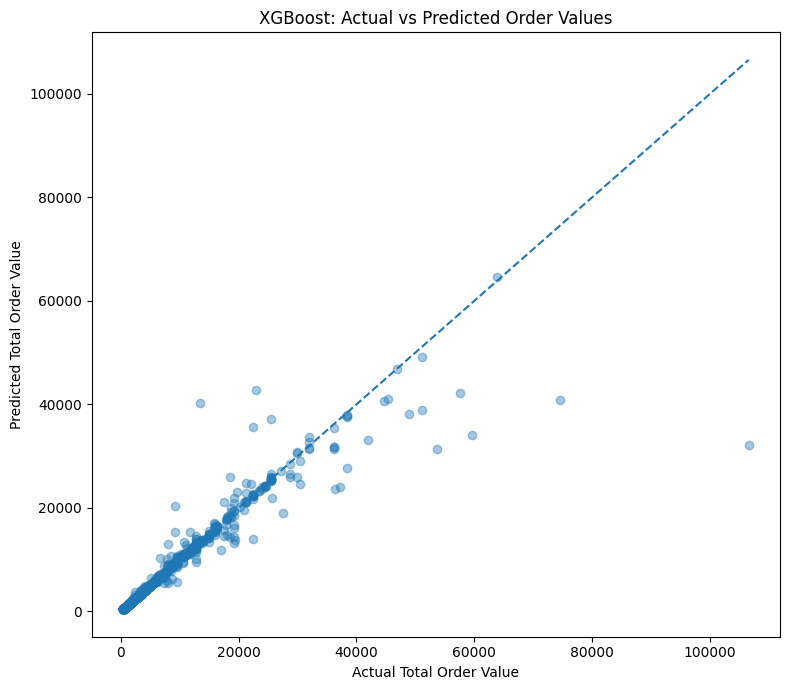

In [ ]:
import matplotlib.pyplot as plt


required_columns = {
    "total_price",
    "prediction_label"
}

missing_columns = (
    required_columns
    - set(final_predictions_all.columns)
)

if missing_columns:
    raise KeyError(
        f"Missing prediction columns: {missing_columns}"
    )


actual_values = final_predictions_all["total_price"]
predicted_values = final_predictions_all["prediction_label"]

minimum_value = min(
    actual_values.min(),
    predicted_values.min()
)

maximum_value = max(
    actual_values.max(),
    predicted_values.max()
)


plt.figure(figsize=(8, 7))

plt.scatter(
    actual_values,
    predicted_values,
    alpha=0.4
)

# Perfect-prediction reference line
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.xlabel("Actual Total Order Value")
plt.ylabel("Predicted Total Order Value")

plt.title(
    "XGBoost: Actual vs Predicted Order Values"
)

plt.tight_layout()
plt.show()

## Holdout Prediction Plot

The diagonal reference line represents perfect predictions. Observations close
to this line have relatively small prediction errors, while observations
farther from the line indicate larger errors.

The plot is used alongside RMSE, MAE and R² to determine whether prediction
errors are distributed across the target range or concentrated among the
highest-value orders.

## Largest Prediction Errors

In [ ]:
final_error_analysis = final_predictions_all.copy()

final_error_analysis["Residual"] = (
    final_error_analysis["total_price"]
    - final_error_analysis["prediction_label"]
)

final_error_analysis["Absolute Error"] = (
    final_error_analysis["Residual"].abs()
)

final_error_analysis["Absolute Percentage Error"] = np.where(
    final_error_analysis["total_price"] != 0,
    (
        final_error_analysis["Absolute Error"]
        / final_error_analysis["total_price"]
        * 100
    ),
    np.nan
)


largest_errors = (
    final_error_analysis
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .head(20)
)


error_columns = [
    column
    for column in [
        "model",
        "quantity",
        "category_1",
        "category_2",
        "frame_material",
        "city",
        "state",
        "total_price",
        "prediction_label",
        "Residual",
        "Absolute Error",
        "Absolute Percentage Error"
    ]
    if column in largest_errors.columns
]


display(
    largest_errors[
        error_columns
    ]
    .style
    .format({
        column: format_string
        for column, format_string in {
            "total_price": "{:,.2f}",
            "prediction_label": "{:,.2f}",
            "Residual": "{:,.2f}",
            "Absolute Error": "{:,.2f}",
            "Absolute Percentage Error": "{:.2f}%"
        }.items()
        if column in error_columns
    })
    .hide(axis="index")
)

model,quantity,category_1,category_2,frame_material,city,state,total_price,prediction_label,Residual,Absolute Error,Absolute Percentage Error
Supersix Evo Hi-Mod Team,10,Road,Elite Road,Carbon,Ann Arbor,MI,"106,600.00","32,184.09","74,415.91","74,415.91",69.81%
Supersix Evo Hi-Mod Team,7,Road,Elite Road,Carbon,Las Vegas,NV,"74,620.00","40,759.86","33,860.14","33,860.14",45.38%
Supersix Evo 105,6,Road,Elite Road,Carbon,Kansas City,KS,"13,440.00","40,349.43","-26,909.43","26,909.43",200.22%
Synapse Hi-Mod Disc Red,8,Road,Endurance Road,Carbon,San Francisco,CA,"59,680.00","33,998.38","25,681.62","25,681.62",43.03%
Trigger Carbon 2,9,Mountain,Over Mountain,Carbon,Los Angeles,CA,"53,730.00","31,363.10","22,366.90","22,366.90",41.63%
Jekyll Carbon 3,6,Mountain,Over Mountain,Carbon,Columbus,OH,"23,040.00","42,751.35","-19,711.35","19,711.35",85.55%
Synapse Hi-Mod Disc Black Inc.,6,Road,Endurance Road,Carbon,Ithaca,NY,"57,540.00","42,112.97","15,427.03","15,427.03",26.81%
Fat CAAD1,10,Mountain,Fat Bike,Aluminum,Kansas City,KS,"37,300.00","23,966.59","13,333.41","13,333.41",35.75%
Slice Hi-Mod Dura Ace D12,5,Road,Triathalon,Carbon,Ann Arbor,MI,"22,500.00","35,555.02","-13,055.02","13,055.02",58.02%
Jekyll Carbon 2,6,Mountain,Over Mountain,Carbon,Providence,RI,"36,420.00","23,635.58","12,784.42","12,784.42",35.10%


### Prediction Error Analysis

The largest prediction errors are concentrated among the most unusual
high-value orders. This is consistent with the higher RMSE observed on the
complete dataset and supports retaining MAE alongside RMSE when evaluating
model performance.

These observations are not automatically treated as data errors because many
represent legitimate premium products or larger order quantities.

## IQR Sensitivity Holdout Evaluation

In [ ]:
# ---------------------------------------------------------
# Sensitivity-model holdout evaluation
# ---------------------------------------------------------

xgb_holdout_iqr = exp_iqr.predict_model(
    result_iqr.best
)

print(
    "XGBoost holdout metrics — "
    "1.5 × IQR sensitivity dataset"
)

display(
    xgb_holdout_iqr.metrics
)

XGBoost holdout metrics — 1.5 × IQR sensitivity dataset


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,XGBRegressor,16.1408,12349.4375,111.128,0.9975,0.0182,0


In [ ]:
all_data_metrics = (
    xgb_holdout_all.metrics
    .copy()
    .assign(
        Dataset="All observations",
        Role="Primary model"
    )
)

iqr_data_metrics = (
    xgb_holdout_iqr.metrics
    .copy()
    .assign(
        Dataset="1.5 × IQR sensitivity",
        Role="Sensitivity analysis"
    )
)

xgb_sensitivity_summary = pd.concat(
    [
        all_data_metrics,
        iqr_data_metrics
    ],
    ignore_index=True
)


summary_columns = [
    column
    for column in [
        "Dataset",
        "Role",
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "RMSLE"
    ]
    if column in xgb_sensitivity_summary.columns
]


display(
    xgb_sensitivity_summary[
        summary_columns
    ]
    .style
    .format({
        column: format_string
        for column, format_string in {
            "MAE": "{:,.2f}",
            "MSE": "{:,.2f}",
            "RMSE": "{:,.2f}",
            "R2": "{:.4f}",
            "RMSLE": "{:.4f}"
        }.items()
        if column in summary_columns
    })
    .hide(axis="index")
)

Dataset,Role,MAE,MSE,RMSE,R2,RMSLE
All observations,Primary model,139.43,"2,399,176.25","1,548.93",0.9105,0.0468
1.5 × IQR sensitivity,Sensitivity analysis,16.14,"12,349.44",111.13,0.9975,0.0182


## Sensitivity Analysis

XGBoost was the strongest cross-validated model for both the complete dataset
and the 1.5×IQR sensitivity dataset. This indicates that the preferred
algorithm is not dependent on the outlier-treatment decision.

The filtered dataset produces substantially smaller errors because it excludes
the upper tail of the order-value distribution. These raw error values should
not be interpreted as a direct like-for-like improvement over the complete
dataset.

The complete-data XGBoost model remains the final model because it represents
the full business population, including legitimate high-value and
high-quantity orders.

## Final Price-Driver Analysis

Permutation importance is used on the holdout data to estimate how strongly
the final XGBoost model relies on each original predictor.

The importance score measures the increase in prediction error when a feature
is randomly shuffled. Larger values indicate greater predictive contribution.

Because several product variables contain overlapping information, these
results should be interpreted as predictive importance rather than causal
effects.

In [ ]:
from sklearn.inspection import permutation_importance

# Holdout predictors and target from the PyCaret prediction output
X_holdout = final_predictions_all[
    [
        "quantity",
        "model",
        "category_1",
        "category_2",
        "frame_material",
        "city",
        "state"
    ]
].copy()

y_holdout = final_predictions_all["total_price"].copy()

# Measure how much predictive performance deteriorates
# when each feature is randomly shuffled
perm_importance = permutation_importance(
    selected_model_all,
    X_holdout,
    y_holdout,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42
)

feature_importance = pd.DataFrame({
    "Feature": X_holdout.columns,
    "Importance": perm_importance.importances_mean,
    "Std": perm_importance.importances_std
}).sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance.style.format({
        "Importance": "{:.2f}",
        "Std": "{:.2f}"
    }).hide(axis="index")
)

Feature,Importance,Std
frame_material,3057.81,50.78
model,2827.31,28.98
quantity,1631.69,37.40
category_2,595.67,13.71
category_1,173.05,6.41
city,3.57,5.90
state,1.59,2.55


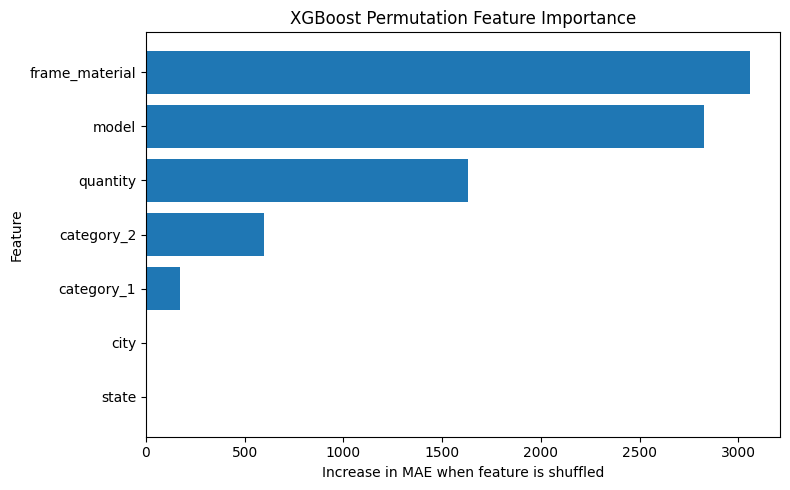

In [ ]:
import matplotlib.pyplot as plt

plot_data = feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Increase in MAE when feature is shuffled")
plt.ylabel("Feature")
plt.title("XGBoost Permutation Feature Importance")

plt.tight_layout()
plt.show()

### Driver Interpretation

Permutation importance identified frame material as the strongest predictive
driver, with an increase in MAE of approximately 3,058 when shuffled. Bike
model was the second strongest driver at approximately 2,827, followed by
order quantity at approximately 1,632.

Product categories provided additional predictive information, while city
and state had comparatively little effect on model performance.

This indicates that total order value is driven primarily by product
characteristics and order size rather than geography.

These values represent predictive contribution rather than causal effects.
Bike model, category and frame material contain overlapping information, so
their individual importance should be interpreted with caution.

## Conclusion

The original XGBoost regressor was selected as the final model configuration
based on cross-validation performance within the training data.

Hyperparameter tuning, stacking and voting were tested using the same
cross-validation framework, but none improved RMSE relative to the original
XGBoost model. The simpler original XGBoost configuration was therefore
retained.

After model selection was complete, the selected XGBoost model was evaluated
once on the untouched 30% test set. On these unseen observations, it achieved:

- R² of approximately 0.911
- RMSE of approximately 1,549
- MAE of approximately 139
- RMSLE of approximately 0.047

These test-set results provide the primary estimate of the model's
generalisation performance.

The 1.5×IQR sensitivity analysis also identified XGBoost as the strongest
algorithm. However, the complete business population remains the preferred
modelling population because the excluded high-value observations appear to
represent legitimate premium or high-quantity orders rather than obvious
data errors.

Permutation importance indicates that frame material, bike model and order
quantity are the strongest predictive drivers of total order value, while
geographic variables contribute comparatively little predictive information.

Overall, the project demonstrates a clear separation between model selection
and final evaluation: cross-validation was used to choose the model, while
the untouched test set was reserved for assessing performance on unseen data.

## Limitations and Next Steps

Several limitations should be considered when interpreting the results.

- The dataset contains overlapping product attributes. Bike model, category
  and frame material are strongly related, which limits interpretation of
  individual feature effects.
- The random train/test split evaluates prediction of new orders drawn from
  the same historical population. It does not directly measure performance
  on completely new bike models or future market conditions.
- Geographic variables may capture historical sales patterns rather than
  causal location effects.
- High-value orders are harder to predict and contribute disproportionately
  to RMSE.

Possible extensions include:

- time-based validation if transaction dates are available;
- testing generalisation to unseen bike models;
- additional pricing or customer features where available;
- monitoring prediction error by order size;
- periodic model retraining as new order data becomes available.

In [ ]:
import sys
import pandas as pd
import sklearn
import xgboost
import pycaret

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("pycaret:", pycaret.__version__)

Python: 3.13.15
pandas: 2.2.3
scikit-learn: 1.6.1
xgboost: 3.4.1
pycaret: 4.0.0a8


## Optional Deployment Refit

The model below is refitted on all available observations only after model
selection and test-set evaluation have been completed.

This refitted model is intended as a production-ready artifact. Its
performance is not re-evaluated here because the original test set has now
been incorporated into training.

All reported generalisation metrics in this project come from the untouched
test-set evaluation performed before this refit.

In [ ]:
# ---------------------------------------------------------
# Refit the selected model on the complete dataset
# ---------------------------------------------------------

finalized_xgb_result = exp_all.finalize_model(
    selected_model_all
)

final_xgb_pipeline = (
    finalized_xgb_result.pipeline
)

print(
    "Final XGBoost pipeline fitted on all observations."
)

Final XGBoost pipeline fitted on all observations.


# EXPLORATORY APPENDIX: Exploratory Threshold Check

## Sensitivity Analysis: Impact of Outlier Threshold Selection



The appendix reproduces an earlier exploratory threshold experiment using an
80/20 split. These results are not used for final model selection; the final
workflow uses the consistent 70/30 evaluation framework above.

In [ ]:
# Exploratory four-threshold comparison; final workflow uses all data vs 1.5×IQR.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
import pandas as pd
import numpy as np

results = []

# -----------------------------------------
# 1. NO OUTLIER REMOVAL
# -----------------------------------------

filtered_df = short_df.copy()

X = filtered_df.drop(columns=["total_price"])
y = filtered_df["total_price"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

results.append({
    "IQR Multiplier": "None",
    "Rows Remaining": len(filtered_df),
    "Rows Removed": 0,
    "% Removed": 0,
    "R²": r2_score(y_test, predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
    "MAE": mean_absolute_error(y_test, predictions)
})


# -----------------------------------------
# 2. TEST DIFFERENT IQR THRESHOLDS
# -----------------------------------------

for multiplier in [1.5, 1.0, 0.5]:

    Q1 = short_df["total_price"].quantile(0.25)
    Q3 = short_df["total_price"].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    filtered_df = short_df[
        (short_df["total_price"] >= lower_bound) &
        (short_df["total_price"] <= upper_bound)
    ].copy()

    removed = len(short_df) - len(filtered_df)
    removed_pct = removed / len(short_df) * 100

    X = filtered_df.drop(columns=["total_price"])
    y = filtered_df["total_price"]

    X = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    results.append({
        "IQR Multiplier": multiplier,
        "Rows Remaining": len(filtered_df),
        "Rows Removed": removed,
        "% Removed": removed_pct,
        "R²": r2_score(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "MAE": mean_absolute_error(y_test, predictions)
    })


iqr_comparison = pd.DataFrame(results)

iqr_comparison

,IQR Multiplier,Rows Remaining,Rows Removed,% Removed,R²,RMSE,MAE
0,None,15644,0,0.000000,0.798026,2396.859396,942.902238
1,1.5,14310,1334,8.527231,0.938796,547.358124,266.601799
2,1.0,13872,1772,11.327026,0.937624,483.261576,228.564539
3,0.5,13033,2611,16.690105,0.944453,375.777212,184.529122
